In [1]:
import pybamm

# Choose/change the whole parameter set

In-built parameter sets: https://docs.pybamm.org/en/latest/source/api/parameters/parameter_sets.html 


In [2]:
# Choose a parameter set.
parameter_values = pybamm.ParameterValues("Chen2020")

In [3]:
# Print all parameter values.
parameter_values

{'Ambient temperature [K]': 298.15,
 'Bulk solvent concentration [mol.m-3]': 2636.0,
 'Cation transference number': 0.2594,
 'Cell cooling surface area [m2]': 0.00531,
 'Cell thermal expansion coefficient [m.K-1]': 1.1e-06,
 'Cell volume [m3]': 2.42e-05,
 'Contact resistance [Ohm]': 0,
 'Current function [A]': 5.0,
 'EC diffusivity [m2.s-1]': 2e-18,
 'EC initial concentration in electrolyte [mol.m-3]': 4541.0,
 'Electrode height [m]': 0.065,
 'Electrode width [m]': 1.58,
 'Electrolyte conductivity [S.m-1]': <function electrolyte_conductivity_Nyman2008 at 0x11ae791c0>,
 'Electrolyte diffusivity [m2.s-1]': <function electrolyte_diffusivity_Nyman2008 at 0x11ae79120>,
 'Initial SEI thickness [m]': 5e-09,
 'Initial concentration in electrolyte [mol.m-3]': 1000.0,
 'Initial concentration in negative electrode [mol.m-3]': 29866.0,
 'Initial concentration in positive electrode [mol.m-3]': 17038.0,
 'Initial temperature [K]': 298.15,
 'Lithium interstitial reference concentration [mol.m-3]': 15

In [4]:
# Print a specific parameter value.
parameter_values["Electrode width [m]"]

1.58

In [5]:
# Search an INPUT parameter value.
parameter_values.search("electrolyte")

Results for 'electrolyte': ['EC initial concentration in electrolyte [mol.m-3]', 'Negative electrode Bruggeman coefficient (electrolyte)', 'Positive electrode Bruggeman coefficient (electrolyte)', 'Separator Bruggeman coefficient (electrolyte)', 'Initial concentration in electrolyte [mol.m-3]', 'Electrolyte diffusivity [m2.s-1]', 'Electrolyte conductivity [S.m-1]']
EC initial concentration in electrolyte [mol.m-3] -> 4541.0
Negative electrode Bruggeman coefficient (electrolyte) -> 1.5
Positive electrode Bruggeman coefficient (electrolyte) -> 1.5
Separator Bruggeman coefficient (electrolyte) -> 1.5
Initial concentration in electrolyte [mol.m-3] -> 1000.0
Electrolyte diffusivity [m2.s-1] -> <function electrolyte_diffusivity_Nyman2008 at 0x11ae79120>
Electrolyte conductivity [S.m-1] -> <function electrolyte_conductivity_Nyman2008 at 0x11ae791c0>


In [6]:
# Run a simulation with the chosen parameter set.
model = pybamm.lithium_ion.DFN()
sim = pybamm.Simulation(model, parameter_values=parameter_values)
sim.solve([0, 3600])
sim.plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=3555.449960779094, step=35.55449960779094), …

# Change individual parameters

In [7]:
# Parameters can either have a constant value or be a function of a model variable. Check the parameter type.
# A "FunctionParameter" can be defined as a constant, but a "Parameter" cannot be defined as a dependent function.
model.print_parameter_info()

┌───────────────────────────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Parameter                                                 │ Type of parameter                                                                                                                                                                                           │
├───────────────────────────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ Negative electrode Bruggeman coefficient (electrode)      │ Parameter                                                                                                                             

# Constant parameters

In [8]:
# Change "Current function [A]" as a constant value. 
parameter_values["Current function [A]"] = 10

In [9]:
# Run the simulation with updated parameters.
sim = pybamm.Simulation(model, parameter_values=parameter_values)
sim.solve([0, 3600])
sim.plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=1703.057857583923, step=17.03057857583923), …

# Function parameters

In [10]:
# Customize the function of "Current function [A]" to be sinusoidal, with its dependency on Time [s].
import numpy as np

def my_current(t):
    return pybamm.sin(2 * np.pi * t / 60)

parameter_values["Current function [A]"] = my_current

In [11]:
# Pass "t_eval" to be an array of the points we want to evaluate our solution to the solver (rather than the start and end points only) to make sure we have enough time points to resolve the sinusoidal function in our output.
sim = pybamm.Simulation(model, parameter_values=parameter_values)
t_eval = np.arange(0, 120, 1) # 0 to 120 seconds, with 1 second intervals
sim.solve(t_eval=t_eval)
sim.plot(["Current [A]", "Voltage [V]"])

interactive(children=(FloatSlider(value=0.0, description='t', max=36.17456735351961, step=0.36174567353519615)…

# Input parameters

If the value of a parameter is expected to change often (e.g. running a parameter sweep), it is more convenient to set a parameter as an “input parameter”

To set a parameter as an input parameter, its value can be set to the string "input" in the parameter values dictionary.

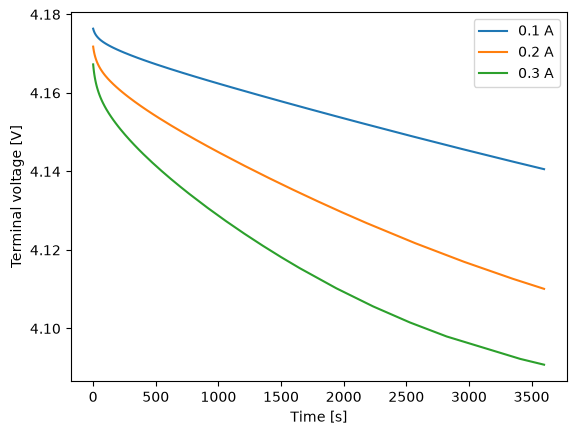

In [12]:
import matplotlib.pyplot as plt

parameter_values["Current function [A]"] = "[input]"
sim = pybamm.Simulation(model, parameter_values=parameter_values)
solutions = []
for c in [0.1, 0.2, 0.3]:
    soln = sim.solve([0, 3600], inputs={"Current function [A]": c})
    plt.plot(soln["Time [s]"].entries, soln["Voltage [V]"].entries, label=f"{c} A")
    solutions.append(soln["Terminal voltage [V]"].entries)
plt.xlabel("Time [s]")
plt.ylabel("Terminal voltage [V]")
plt.legend()
plt.show()

# Define a new parameter set

In [13]:
# Define a new parameter set from scratch. Initialize a "ParameterValues" object with a dictionary of parameter names and values. The values can be either constants or functions of model variables.
def cube(t):
    return t**3     #t^3

parameter_values = pybamm.ParameterValues(
    {
        "Negative electrode thickness [m]": 1e-4,
        "Positive electrode thickness [m]": 1.2e-4,
        "Current function [A]": cube,       #I = t^3
    }
)